## Домашнее задание: "Детекция объектов на изображении"

ФИО: Козлов Сергей Александрович

## Цель задания:
Научиться самостоятельно решать задачу детекции.
## Описание задания:
В рамках данного домашнего задания предлагается решить задачу детекции мячей и настроить полный пайплайн обучения модели.

Процесс выполнения задания следующий:

0. Выбор модели детекции для обучения:
    1. Выберите модель детекции для выполнения домашнего задания. Любую, кроме RetinaNet. Ее реализацию можно взять из открытых источников. Модель можно брать предобученную ( в этом случае в пункте 4. показать влияние предобучения на финальное качество).
    2. Полезные ссылки: [PyTorch Vision Models](https://pytorch.org/vision/stable/models.html) (блок Object Detection), [SOTA модели детекции](https://paperswithcode.com/sota/object-detection-on-coco), [Возможный пример кода](https://github.com/AlekseySpasenov/dl-course/blob/autumn_2023/lecture8/detection_example/pytorch_detection_workshop.ipynb)
    3. Вы можете использовать RetinaNet, которая была реализована на семинаре, но это приведет к снижению оценки на **–2.5 балла**, так как задания 1.1 и 2.1 уже были выполнены в рамках занятия.

1. Подготовка обучающего набора данных
    0. Для выполнения задания используйте датасет с изображениями мячей, который использовался на семинаре.
    1. Реализуйте корректный класс Dataset и Dataloader для выбранной модели (должен работать форвард вашей модели на том, что выходит из даталоадера) **0.5 балла**.
    2. Добавьте простые аугментации в датасет (аугментации, не затрагивающие изменение ground-truth bounding box) **0.5 балла**.
    3. Внедрите сложные аугментации (аугментации, затрагивающие изменение ground-truth bounding box. Например, аффинные преобразования: сдвиг, поворот и т.д.) **0.5 балла**.

    4. Полезные ссылки: https://pytorch.org/vision/stable/transforms.html , https://albumentations.ai

2. Реализация корректного train-loop и обучение модели:  
    1. Реализуйте эффективный train-loop для вашей модели и проведите обучение **2 балла**.
    2. Выполните несколько запусков обучения с различными параметрами, например: сравните влияние различных аугментаций, оцените влияние того была предобучена модель или нет, сравните результаты при изменении гиперпараметров итд (на ваш выбор) **0.5 балла**.

3. Валидация обученных моделей на тестовой выборке, вычисление метрики mAP
    1. Оцените качество моделей на тестовой части данных и рассчитайте метрику mAP **0.5 балл**
    2. Полезные ссылки: [mean_average_precision](https://github.com/bes-dev/mean_average_precision)

4. Выводы **0.5 балл**:
    1. Проанализируйте результаты обучения, визуально оцените качество работы модели.
    2. Прокомментируйте распространенные ошибки модели и предложите пути для улучшения финального решения.

# 0

выберем Faster R-CNN

In [1]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, ssdlite320_mobilenet_v3_large

fasterrcnn = fasterrcnn_resnet50_fpn_v2(pretrained=True)
fasterrcnn.eval()

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

# 1

Image shape (540, 800, 3)


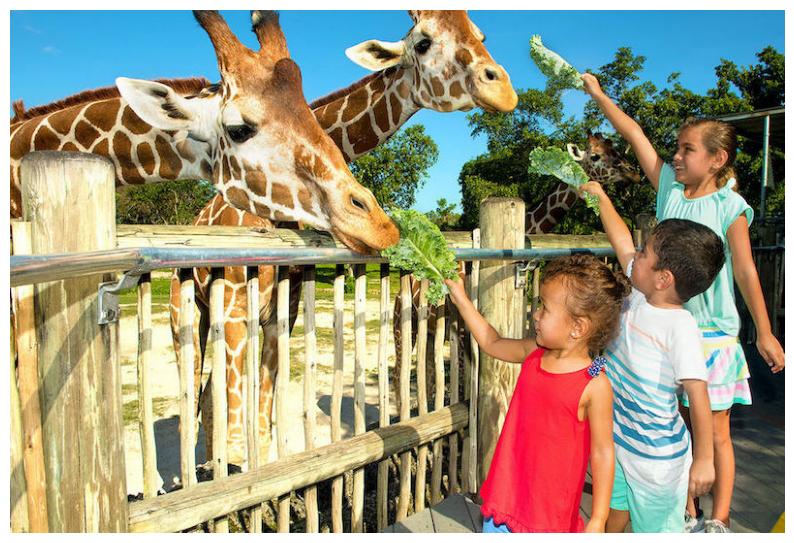

In [2]:
import cv2
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_tensor, normalize

def show_image(image, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

image_example = cv2.imread("workshop_detection/images/zoo.jpg")


image_example = cv2.cvtColor(image_example, cv2.COLOR_BGR2RGB)
print("Image shape", image_example.shape)

show_image(image_example)

# FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT.transforms

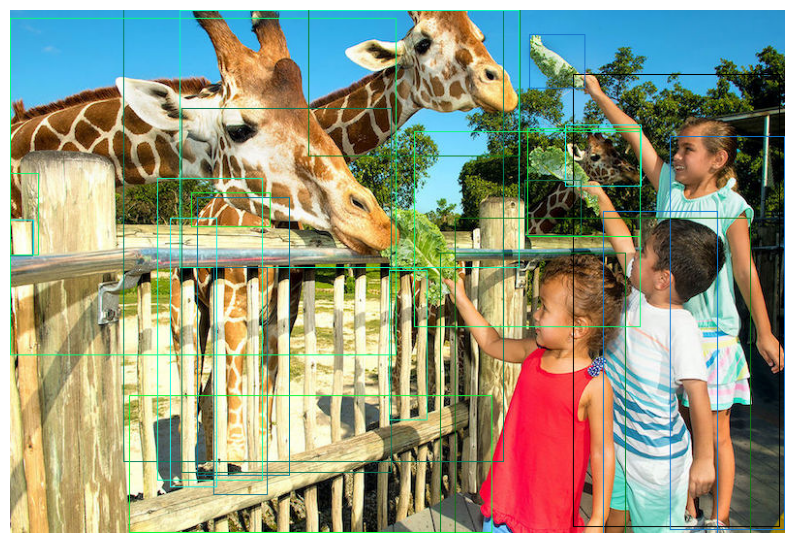

In [3]:
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as F

pred = fasterrcnn.forward(to_tensor(image_example).unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(to_tensor(image_example), pred["boxes"])
)
show_image(image)

Реализуем dataset и dataloader

In [4]:
import os
import json

import torch
from torch.utils.data import Dataset, DataLoader

class BallDataset(Dataset):
    def __init__(self, pathfile, root_dir, transform=None):
        with open(pathfile, "rt") as f:
            self.data = json.load(f)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        key = list(self.data.keys())[idx]

        img_name = os.path.join(self.root_dir, key)
        image = cv2.imread(img_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes = torch.tensor(self.data[key])
        temp = torch.zeros_like(boxes[:, 1])
        temp.copy_(boxes[:, 1])
        boxes[:, 1] = boxes[:, 2]
        boxes[:, 2] = temp
        H = image.shape[0]
        W = image.shape[1]
        boxes[:, 0] *= W
        boxes[:, 1] *= H
        boxes[:, 2] *= W
        boxes[:, 3] *= H

        if self.transform:
            augmented = self.transform(image=image, bboxes=boxes.numpy())
            image = augmented["image"]
            boxes = torch.tensor(augmented["bboxes"])

        return to_tensor(image), boxes
        

In [5]:
import albumentations as A

train_transform = A.Compose([
    A.RandomCrop(width=450, height=450, p=1.0), # Example random crop
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='pascal_voc')
)

test = BallDataset(
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_val.json",
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball",
    train_transform
)

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\utils.py:352: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


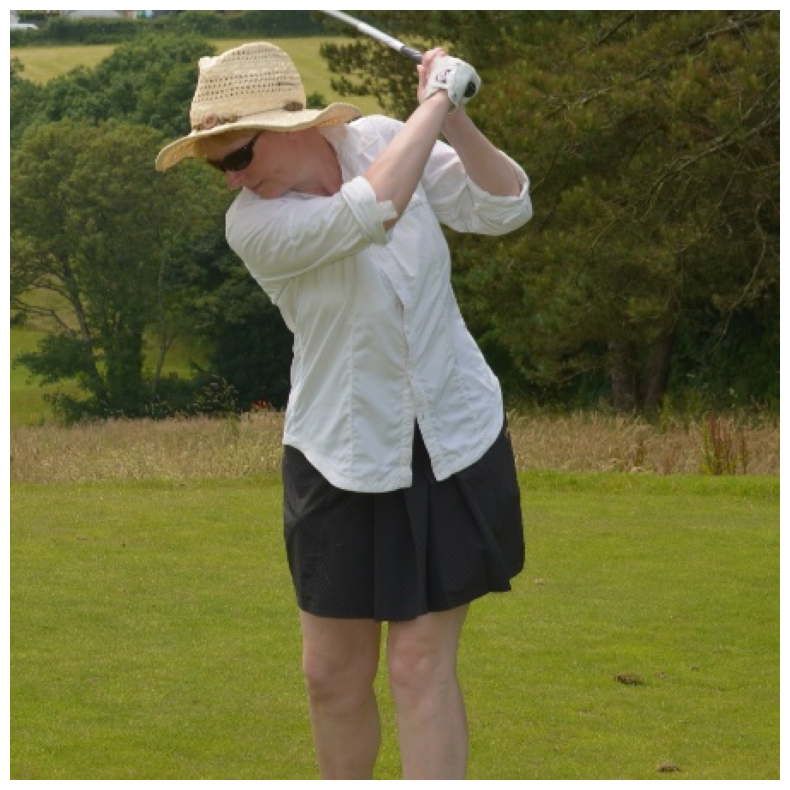

In [6]:
img, box = test[2]
image = F.to_pil_image(
    draw_bounding_boxes(img, box)
)
show_image(image)

Создадим и проверим Dataloader

In [7]:
def ball_collate_fn(batch):
    img_batch = []
    target_batch = []
    for img, boxes in batch:
        img_batch.append(img)
        target_batch.append(
            {
                "boxes": boxes,
                "labels": torch.ones(boxes.shape[0], dtype=torch.int64)
            }
        )
    return img_batch, target_batch

In [8]:
train_transform = A.Compose([
    A.Resize(width=100, height=100, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='pascal_voc')
)

test = BallDataset(
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_val.json",
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball",
    train_transform
)

loader = DataLoader(test, batch_size=8, shuffle=True, collate_fn=ball_collate_fn)

In [9]:
batch = next(iter(loader))

In [ ]:
# fasterrcnn.train()
# fasterrcnn(*batch)

{'loss_classifier': tensor(0.2514, grad_fn=<NllLossBackward0>),
 'loss_box_reg': tensor(0.0542, grad_fn=<DivBackward0>),
 'loss_objectness': tensor(0.1181, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_rpn_box_reg': tensor(0.0288, dtype=torch.float64, grad_fn=<DivBackward0>)}

dataloader заработал

добавим аугментации

In [10]:
train_transform = A.Compose([
    # Простые аугментации
    A.RandomBrightnessContrast(p=0.2),
    A.Blur(p=0.2),
    A.GaussNoise(p=0.2),
    # Сложные аугментации
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=(-15, 15), p=0.5),
    A.RandomGridShuffle(p=0.2)

], bbox_params=A.BboxParams(format='pascal_voc')
)

конечные датасеты и лооудеры

In [11]:
train_dataset = BallDataset(
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_train.json",
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball",
    train_transform
)
val_dataset = BallDataset(
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball/oi5_ball_filename_to_bbox_val.json",
    "seminar_objdet_retina_oi5_ball/seminar_objdet_retina_oi5_ball"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=ball_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True, collate_fn=ball_collate_fn)

# 2

In [14]:
def train_loop(network, n_epochs, device, train_loader, test_loader):
    network.to(device)
    optimizer = torch.optim.Adam(network.parameters())
    train_loss_history = []
    val_loss_history = []
    for epoch in range(n_epochs):
        network.train()
        epoch_loss = 0.0
        for imgs, targets in train_loader:
            optimizer.zero_grad()
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            output = network(imgs, targets)
            loss = sum(loss for loss in output.values())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_loss_history.append(epoch_loss / len(train_loader))

        val_loss = 0.0
        with torch.no_grad():
            for imgs, targets in test_loader:
                imgs = [img.to(device) for img in imgs]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                output = network(imgs, targets)
                loss = sum(loss for loss in output.values())
                val_loss += loss
        val_loss_history.append(val_loss / len(test_loader))

        print('Epoch: {}\tLoss: {:.6f}\tVal Loss: {:.6f}'.format(
                epoch, train_loss_history[-1], val_loss_history[-1]))
    return train_loss_history, val_loss_history

In [16]:
ssdlite = ssdlite320_mobilenet_v3_large(pretrained=True)
train, val = train_loop(ssdlite, 5, "cpu", train_loader, val_loader)

d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Reality\Technopark\NN\homeworks\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSDLite320_MobileNet_V3_Large_Weights.COCO_V1`. You can also use `weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch: 0	Loss: 3.997508	Val Loss: 3.768110
Epoch: 1	Loss: 3.569892	Val Loss: 3.432156
Epoch: 2	Loss: 3.306995	Val Loss: 3.646481
Epoch: 3	Loss: 3.281463	Val Loss: 3.491155
Epoch: 4	Loss: 3.311421	Val Loss: 3.284956


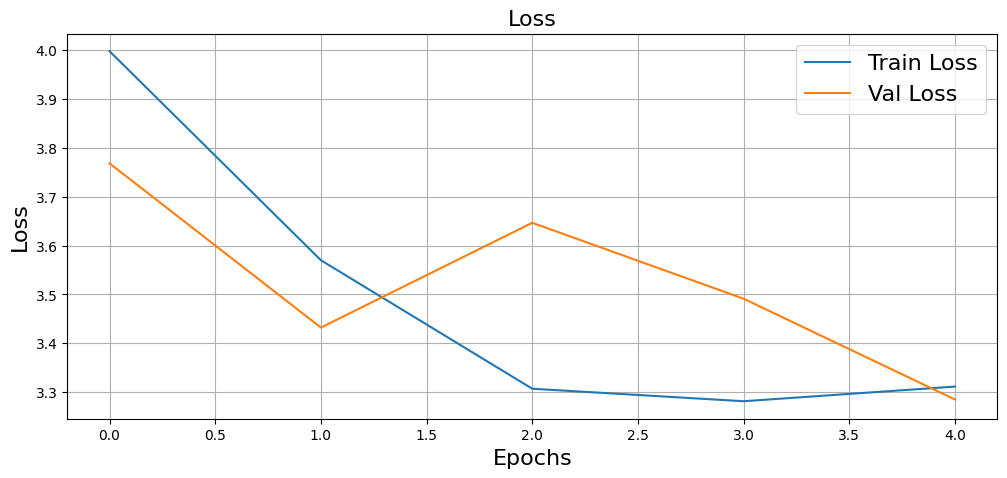

In [17]:
plt.figure(figsize=(12, 5))

plt.title("Loss", fontsize=16)
plt.plot(train, label="Train Loss")
plt.plot(val, label="Val Loss")
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(loc=0, fontsize=16)
plt.grid()
plt.show()

Обучение вышло на плато, на валидации тоже всё неплохо

Модель пришлось поменять по той причине, что faster r-cnn не обучалась ни локально, ни в гугл колабе

Теперь можно посмотреть на качество на картинках, будет отображать топ-5 bboxов

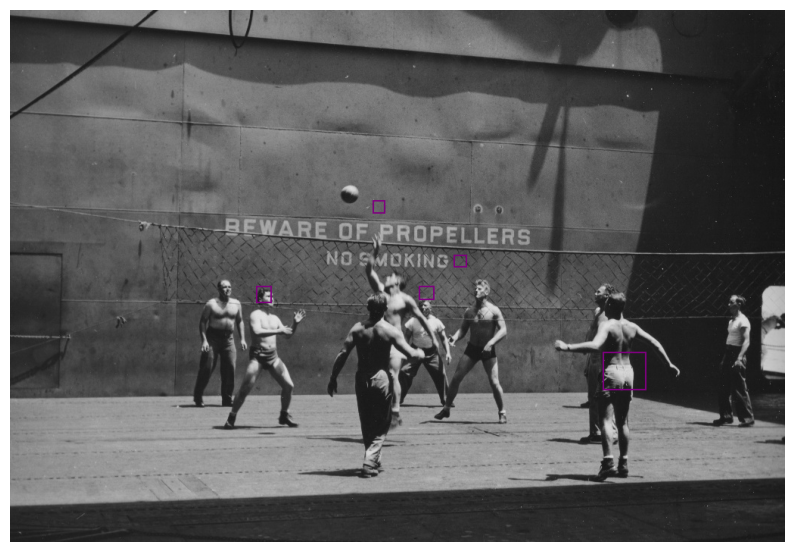

In [48]:
ssdlite.eval()
pred = ssdlite(val_dataset[0][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[0][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

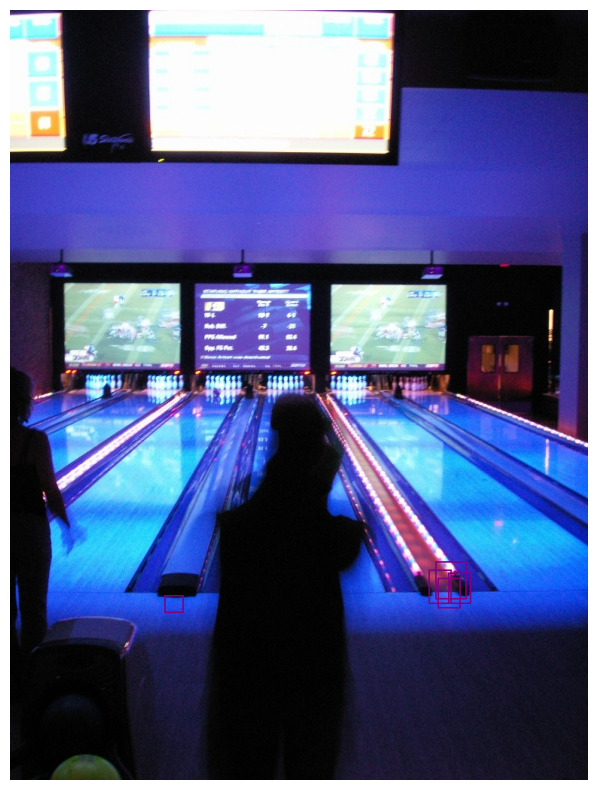

In [47]:
ssdlite.eval()
pred = ssdlite(val_dataset[1][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[1][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

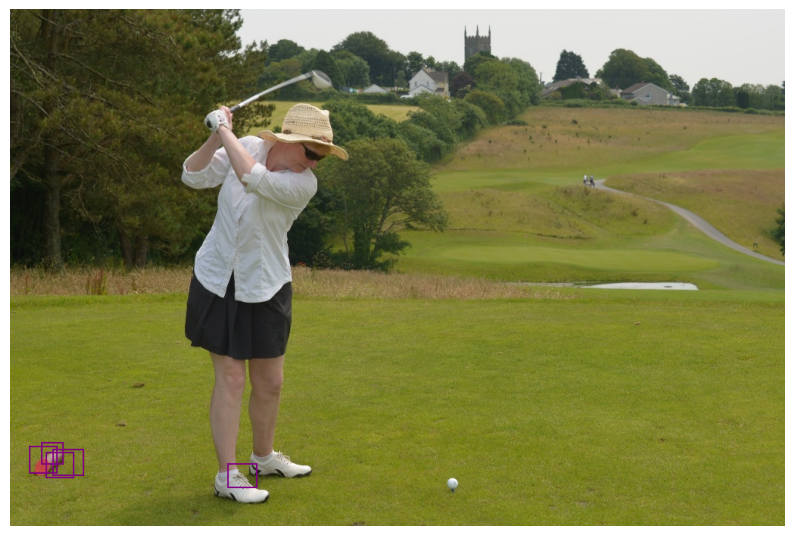

In [46]:
ssdlite.eval()
pred = ssdlite(val_dataset[2][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[2][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

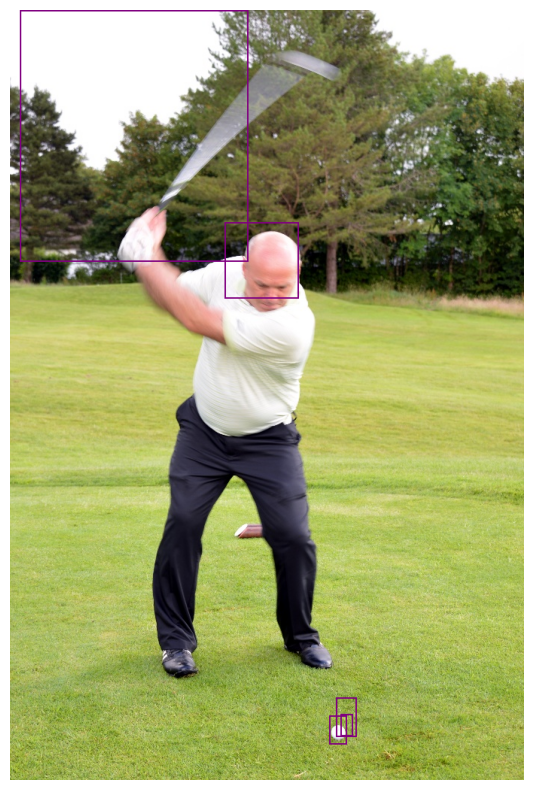

In [45]:
ssdlite.eval()
pred = ssdlite(val_dataset[3][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[3][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

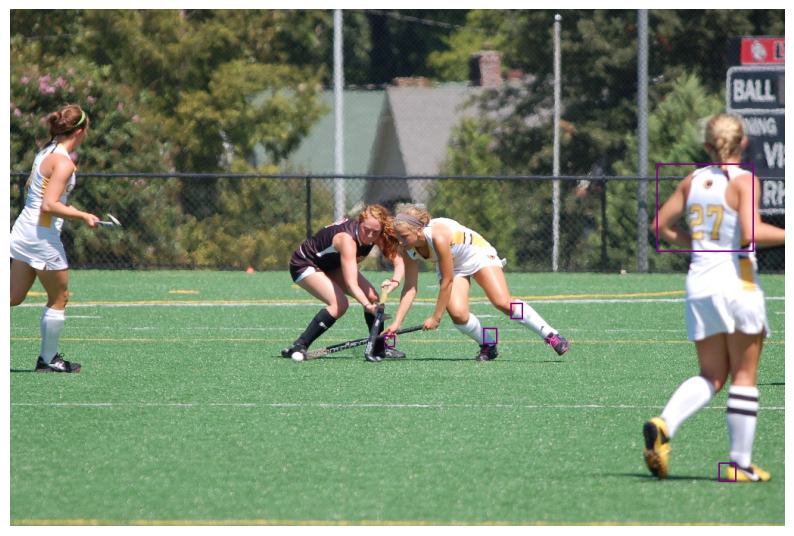

In [44]:
ssdlite.eval()
pred = ssdlite(val_dataset[4][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[4][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

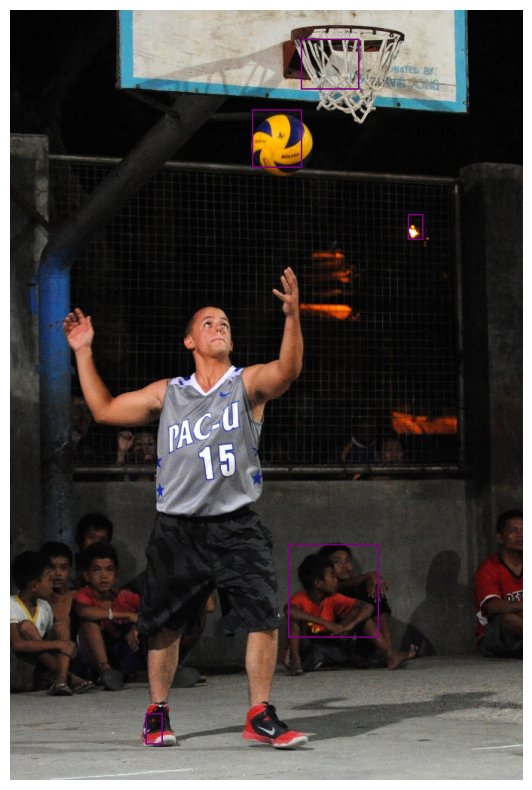

In [43]:
ssdlite.eval()
pred = ssdlite(val_dataset[5][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[5][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

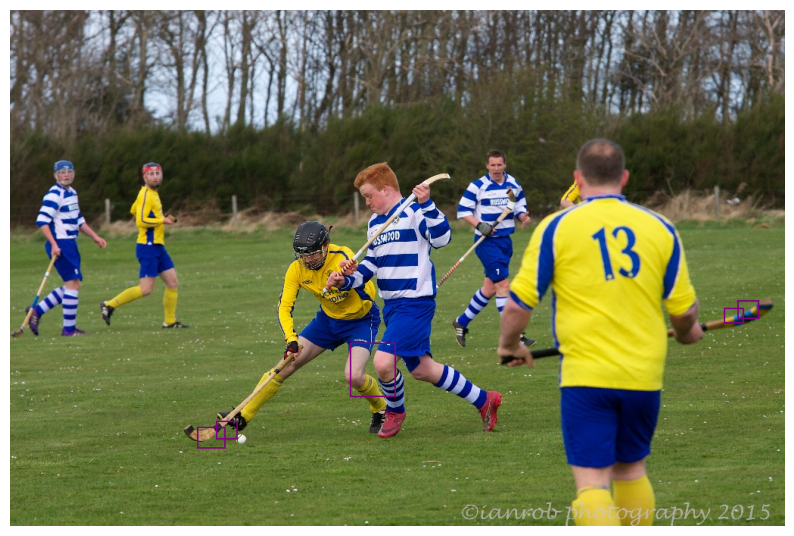

In [50]:
ssdlite.eval()
pred = ssdlite(val_dataset[6][0].unsqueeze(0))[0]
image = F.to_pil_image(
    draw_bounding_boxes(val_dataset[6][0], pred["boxes"][:5], colors="purple", width=2)
)
show_image(image)

Не сказать, что качество стало очень хорошим, но точно заметно, что bboxы стали кучнее вокруг шариков. А в некоторых случаях есть прямое попадание

Возможные улучшения:
- увеличить количество эпох для обучения
- посмотреть на другой модели
- добавить аугментаций, возможно выбранные аугментации оказались недостаточными
- улучшить загрузчик датасета, есть ощущение, что он недостаточно эффективен

### Оставьте обратную связь по занятию №6
Это поможет улучшить курс и сделать следующие занятия ещё лучше!
Форма обратной связи: https://forms.gle/hTfRQaGBrqic7LyP6
